In [1]:
import importlib.resources
import numpy as np
import matplotlib.pyplot as plt
import miepython as mie
from mieScattering import mie_scattering

## NOTE:
#### While the code is correct, Matplotlib has some weird issue that does not plot the 1 MHz lines correctly. 

In [2]:
def compute_imag_permittivity(frequency, conductivity):
    """
    Compute the relative and imaginary part of the permittivity from first principal
    principles.

    Parameters
    ----------  
    frequency : float
        Frequency in Hz.
    conductivity : float
        Conductivity in S/m.
    """
    return 1j * conductivity/(2*np.pi*frequency)

def compute_atten_rate(phi, r, f, epsb=1.78**2, epsp=1):
    """
    Compute the attenuation rate in dB/km due to Mie scattering 

    Parameters
    ---------
    phi: float
        porosity
    r: float
        scatterer radius in m 
    f: float
        frequency in Hz
    epsb: float, default=1.78**2
        background relative permittivity
    epsp: float, default=1
        scattterer relative permittivity

    Return
    ----------
    Na: float
        attenuation rate in dB/km
    """

    Ee_vec = np.zeros(len(r))

    for n in range(len(r)):
        _, _, Ee, _ = mie_scattering(r[n], f, epsp, epsb)
        Ee_vec[n] = Ee
    V_particle = (4/3) * np.pi * r**3
    # make N a (len(r), len(phi)) matrix: porosity divided by particle volume for each radius
    N = phi / V_particle[:, None]

    # compute scattering cross-section
    Qs = Ee_vec * np.pi * r**2
    Qs_array = np.tile(Qs[:, None], (1, len(phi)))
    # compute scattering attenuation rate
    alpha_s = N * Qs_array  
    Na = 10*np.log10(np.exp(1)) * alpha_s * 1e3

    return Na


In [3]:
# define real permittivity for common materials (polar ice sheet and planetary ice)
eps_r_ice = 3.15  # real permittivity of ice
eps_r_dust = 8.8 # real permittivity of dust
eps_r_ldr  = 4.0  # real permittivity of Low Dielectric Rock (LDR)
eps_r_water = 80.1  # real permittivity of water at room temperature
sigma_ice = 10e-6  # S/m, conductivity of pure ice
sigma_freezeon_ice = 30e-6  # S/m, conductivity of freeze-on ice
sigma_ldr = 100e-6  # S/m, conductivity of Low Dielectric Rock (LDR)
sigma_dust = 1.5e-3  # S/m, conductivity of dust
sigma_water = 400e-3 # S/m, conductivity of water

# compute a 1MHz example for each material
f_1 = 1e6    # Hz
f_10 = 10e6  # Hz
f_100 = 100e6  # Hz
epsp_salty_ice = eps_r_ice + compute_imag_permittivity(f_1, sigma_freezeon_ice)
epsp_dust = eps_r_dust + compute_imag_permittivity(f_1, sigma_dust)
epsp_water = eps_r_water + compute_imag_permittivity(f_1, sigma_water)
epsp_ldr = eps_r_ldr + compute_imag_permittivity(f_1, sigma_ldr)
epsb = eps_r_ice + compute_imag_permittivity(f_1, sigma_ice)  # background permittivity (pure ice)

# print
print(f"Salty ice permittivity at 1 MHz: {epsp_salty_ice}")
print(f"Dust permittivity at 1 MHz: {epsp_dust}")
print(f"Water permittivity at 1 MHz: {epsp_water}")
print(f"LDR permittivity at 1 MHz: {epsp_ldr}")
print(f"Background permittivity at 1 MHz: {epsb}")

Salty ice permittivity at 1 MHz: (3.15+4.774648292756861e-12j)
Dust permittivity at 1 MHz: (8.8+2.38732414637843e-10j)
Water permittivity at 1 MHz: (80.1+6.366197723675814e-08j)
LDR permittivity at 1 MHz: (4+1.5915494309189536e-11j)
Background permittivity at 1 MHz: (3.15+1.5915494309189536e-12j)


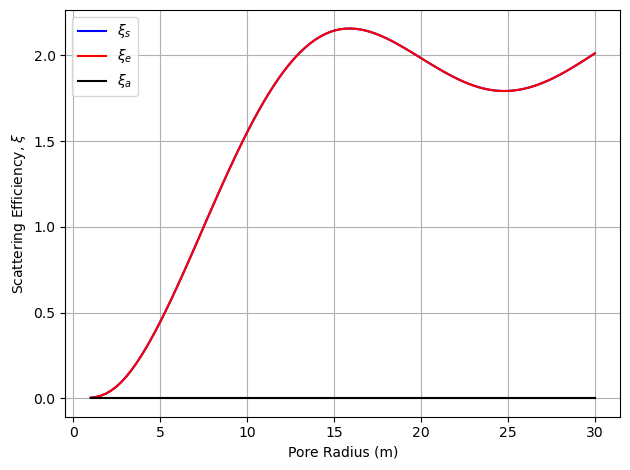

[0.0070611  0.01486404 0.0269569  0.04393721 0.06610805 0.09350567
 0.12595988 0.16316512 0.20474559]
[0.0070611  0.01486404 0.0269569  0.04393721 0.06610805 0.09350567
 0.12595988 0.16316512 0.20474559]
[-8.67361738e-19  0.00000000e+00  1.73472348e-17 -6.93889390e-18
  0.00000000e+00  1.38777878e-17 -2.77555756e-17  0.00000000e+00
  0.00000000e+00]


In [4]:
epsp = 1
epsb = 1.78**2
c = 3e8

f = 9e6  # Hz
lambda_wave = c / f
r = np.linspace(1, 30, 100)  # 100 points by default (MATLAB default is 100)
Es_vec = np.zeros(len(r))
Ee_vec = np.zeros(len(r))
Ea_vec = np.zeros(len(r))

for n in range(len(r)):
    Es, Ea, Ee, Eb = mie_scattering(r[n], f, epsp, epsb)
    Es_vec[n] = Es
    Ee_vec[n] = Ee
    Ea_vec[n] = Ea

# Create figure
plt.figure()
plt.plot(r, Es_vec, 'b', label=r'$\xi_s$')
plt.plot(r, Ee_vec, 'r', label=r'$\xi_e$')
plt.plot(r, Ea_vec, 'k', label=r'$\xi_a$')

plt.xlabel('Pore Radius (m)')
plt.ylabel(r'Scattering Efficiency, $\xi$')
plt.legend(loc='upper left')  # 'NorthWest' → 'upper left'
plt.grid(True)  # Optional: add grid for better readability
plt.tight_layout()  # Optional: adjust layout to prevent label cutoff
plt.show()

print(Es_vec[1:10])
print(Ee_vec[1:10])
print(Ea_vec[1:10])

Material: Dust, Porosity: 0.01, Attenuation at r=0.10 cm:
  Frequency: 1.0 MHz, Attenuation: -4.8082e-11 dB/km
  Frequency: 10.0 MHz, Attenuation: -4.7919e-11 dB/km
  Frequency: 100.0 MHz, Attenuation: -4.5989e-11 dB/km
Material: Dust, Porosity: 0.02, Attenuation at r=0.10 cm:
  Frequency: 1.0 MHz, Attenuation: -9.6163e-11 dB/km
  Frequency: 10.0 MHz, Attenuation: -9.5838e-11 dB/km
  Frequency: 100.0 MHz, Attenuation: -9.1977e-11 dB/km
Material: Dust, Porosity: 0.05, Attenuation at r=0.10 cm:
  Frequency: 1.0 MHz, Attenuation: -2.4041e-10 dB/km
  Frequency: 10.0 MHz, Attenuation: -2.3960e-10 dB/km
  Frequency: 100.0 MHz, Attenuation: -2.2994e-10 dB/km
Material: Dust, Porosity: 0.10, Attenuation at r=0.10 cm:
  Frequency: 1.0 MHz, Attenuation: -4.8082e-10 dB/km
  Frequency: 10.0 MHz, Attenuation: -4.7919e-10 dB/km
  Frequency: 100.0 MHz, Attenuation: -4.5989e-10 dB/km
Material: Dust, Porosity: 0.20, Attenuation at r=0.10 cm:
  Frequency: 1.0 MHz, Attenuation: -9.6163e-10 dB/km
  Frequen

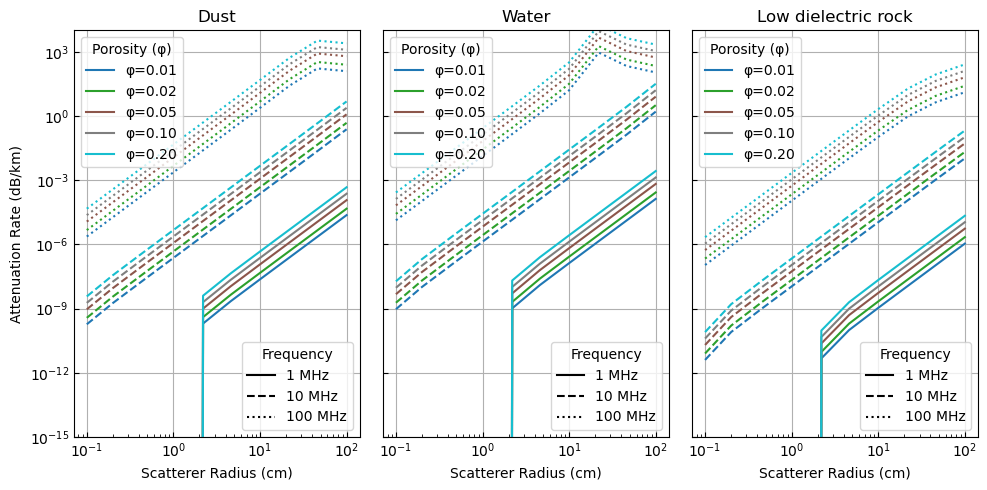

Attenuation rates at 1 MHz for Dust:
 Porosity: 0.01
  Radius: 0.10 cm, Attenuation: -4.8082e-11 dB/km
  Radius: 0.20 cm, Attenuation: -4.7919e-11 dB/km
  Radius: 0.45 cm, Attenuation: -4.5989e-11 dB/km
  Radius: 1.00 cm, Attenuation: -2.4882e-11 dB/km
  Radius: 2.20 cm, Attenuation: 1.9918e-10 dB/km
  Radius: 4.60 cm, Attenuation: 2.2124e-09 dB/km
  Radius: 10.00 cm, Attenuation: 2.3175e-08 dB/km
  Radius: 22.00 cm, Attenuation: 2.4724e-07 dB/km
  Radius: 46.00 cm, Attenuation: 2.2605e-06 dB/km
  Radius: 100.00 cm, Attenuation: 2.3230e-05 dB/km
 Porosity: 0.02
  Radius: 0.10 cm, Attenuation: -9.6163e-11 dB/km
  Radius: 0.20 cm, Attenuation: -9.5838e-11 dB/km
  Radius: 0.45 cm, Attenuation: -9.1977e-11 dB/km
  Radius: 1.00 cm, Attenuation: -4.9763e-11 dB/km
  Radius: 2.20 cm, Attenuation: 3.9835e-10 dB/km
  Radius: 4.60 cm, Attenuation: 4.4247e-09 dB/km
  Radius: 10.00 cm, Attenuation: 4.6351e-08 dB/km
  Radius: 22.00 cm, Attenuation: 4.9447e-07 dB/km
  Radius: 46.00 cm, Attenuation: 4

In [ ]:
# scatterer radii (m) and porosities
r = 1e-3 * np.array([1, 2, 4.5, 10, 22, 46, 100, 220, 460, 1e3]) # 1 cm to 1 m
phi = np.array([0.01, 0.02, 0.05, 0.1, 0.20])

# compute attenuation rate
f_1 = 1e6  # Hz
f_10 = 10e6  # Hz
f_100 = 100e6  # Hz

# two subplots: left uses current epsp (salty ice), right uses epsp_dust
materials = [(eps_r_dust, sigma_dust, 'Dust'), (eps_r_water, sigma_water, 'Water'), (eps_r_ldr, sigma_ldr, 'Low dielectric rock')]
frequencies = [f_1, f_10, f_100]
freq_labels = ['1 MHz', '10 MHz', '100 MHz']
linestyles = ['-', '--', ':']

fig, axs = plt.subplots(1, 3, figsize=(10, 5), sharey=True)
colors = plt.get_cmap('tab10')(np.linspace(0, 1, len(phi)))

for ax, (mat_eps_real, sigma, title) in zip(axs, materials):
    # compute attenuation for the three frequencies with this material permittivity
    mat_eps = [mat_eps_real + compute_imag_permittivity(f, sigma) for f in frequencies]
    Na_list = [compute_atten_rate(phi, r, f, epsb, eps) for f, eps in zip(frequencies, mat_eps)]

    for j, p in enumerate(phi):
        for k, Na in enumerate(Na_list):
            ax.plot(r * 1e2, Na[:, j], color=colors[j], linestyle=linestyles[k],
                    label=f'φ={p:.2f}' if k == 0 else None)
            if k==0:
            #print the attenuation at the smallest radius a
                print(f"Material: {title}, Porosity: {p:.2f}, Attenuation at r={r[0]*1e2:.2f} cm:")
                for f_val, Na_val in zip(frequencies, Na[:, j]):
                    print(f"  Frequency: {f_val/1e6:.1f} MHz, Attenuation: {Na_val:.4e} dB/km")
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim(1e-15, 1e4)  # set y-axis limits
    ax.set_xlabel('Scatterer Radius (cm)')
    ax.set_ylabel('Attenuation Rate (dB/km)' if ax is axs[0] else None)
    ax.grid(True)
    ax.set_title(f'{title}')
    ax.tick_params(axis='both', which='both', direction='in')

    # legend for porosity (colors)
    phi_handles, phi_labels = ax.get_legend_handles_labels()
    # if last subplot
    # if ax is axs[-1]:
    #     leg1 = ax.legend(phi_handles, phi_labels, title='Porosity (φ)', loc='lower left')
    # else:
    #     leg1 = ax.legend(phi_handles, phi_labels, title='Porosity (φ)', loc='upper left')
    leg1 = ax.legend(phi_handles, phi_labels, title='Porosity (φ)', loc='upper left')
    ax.add_artist(leg1)

    # legend for frequency (linestyles) using proxy empty plots, moved to lower right
    freq_proxies = [ax.plot([], [], color='k', linestyle=ls, label=lbl)[0]
                    for ls, lbl in zip(linestyles, freq_labels)]
    ax.legend(handles=freq_proxies, title='Frequency', loc='lower right')

plt.tight_layout()
plt.show()

# save figure
fig.savefig('mie_scattering_attenuation.png', dpi=300)


Na shape  (10, 5)
Values are:  [-6.87582024e-12 -6.86822300e-12 -6.77795759e-12 -5.79102099e-12
  4.68563500e-12  9.88191114e-11  1.07900816e-09  1.15554600e-08
  1.05680800e-07  1.08547290e-06]
Values are:  [-1.37516405e-11 -1.37364460e-11 -1.35559152e-11 -1.15820420e-11
  9.37127000e-12  1.97638223e-10  2.15801632e-09  2.31109200e-08
  2.11361599e-07  2.17094580e-06]
Values are:  [-3.43791012e-11 -3.43411150e-11 -3.38897879e-11 -2.89551049e-11
  2.34281750e-11  4.94095557e-10  5.39504080e-09  5.77773000e-08
  5.28403998e-07  5.42736451e-06]
Values are:  [-6.87582024e-11 -6.86822300e-11 -6.77795759e-11 -5.79102099e-11
  4.68563500e-11  9.88191114e-10  1.07900816e-08  1.15554600e-07
  1.05680800e-06  1.08547290e-05]
Values are:  [-1.37516405e-10 -1.37364460e-10 -1.35559152e-10 -1.15820420e-10
  9.37127000e-11  1.97638223e-09  2.15801632e-08  2.31109200e-07
  2.11361599e-06  2.17094580e-05]


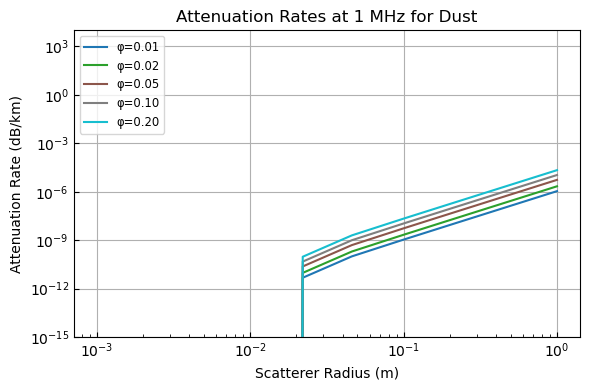

In [26]:
# just plot the attenuation rates from 1MHz case for dust
dust_only = Na_list[0]
print("Na shape ", dust_only.shape)
plt.figure(figsize=(6,4))
colors = plt.get_cmap('tab10')(np.linspace(0, 1, len(phi)))
# three frequencies - each different line style

for j, p in enumerate(phi):
    plt.plot(r, dust_only[:, j], color=colors[j], label=f'φ={p:.2f}')
    print("Values are: ", dust_only[:, j])

plt.xscale('log')
plt.yscale('log')
# plt.xlim(1e0, 1e3)  # set x-axis limits
plt.ylim(1e-15, 1e4)  # set y-axis limits
plt.xlabel('Scatterer Radius (m)')
plt.ylabel('Attenuation Rate (dB/km)')
plt.grid(True)
plt.title('Attenuation Rates at 1 MHz for Dust')
plt.tick_params(axis='both', which='both', direction='in')
plt.legend(loc='upper left', fontsize='small', ncol=1)
plt.tight_layout()
plt.show()

In [ ]:
# common relative permittivity
epsp_water = 88 # water, at 0 degree C
epsp_dust = 8.8 - 1.7e-2j # dust
epsp_salty_ice = 3.5 - 2.7e-20j # salty ice

epsp = epsp_salty_ice
epsb = 1.78**2
c = 3e8

r = 1e-3 * np.array([1, 2, 4.5, 10, 22, 46, 100, 220, 460, 1e3])
phi = np.array([0.01, 0.02, 0.05, 0.1, 0.20])

# compute attenuation rate
f_1 = 1e6  # Hz
f_10 = 10e6  # Hz
f_100 = 100e6  # Hz
Na_1 = compute_atten_rate(phi, r, f_1, epsb, epsp)
Na_10 = compute_atten_rate(phi, r, f_10, epsb, epsp)
Na_100 = compute_atten_rate(phi, r, f_100, epsb, epsp)

# plot all frequencies on one axes; different linestyles for frequencies, different colors for porosities
Na_list = [Na_1, Na_10, Na_100]
linestyles = ['-', '--', ':']
freq_labels = ['1 MHz', '10 MHz', '100 MHz']

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.get_cmap('tab10')(np.linspace(0, 1, len(phi)))

for j, p in enumerate(phi):
    color = colors[j]
    # add a label only once per porosity so the porosity legend is clean
    for k, Na in enumerate(Na_list):
        ax.plot(r * 1e2, Na[:, j], color=color, linestyle=linestyles[k],
                label=f'φ={p:.2f}' if k == 0 else None)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Scatterer Radius (cm)')
ax.set_ylabel('Attenuation Rate (dB/km)')
ax.grid(True)
ax.set_title('Attenuation Rate for Different Frequencies and Porosities')
ax.tick_params(axis='both', which='both', direction='in')

# legend for porosity (colors)
phi_handles, phi_labels = ax.get_legend_handles_labels()
leg1 = ax.legend(phi_handles, phi_labels, title='Porosity (φ)', loc='upper left')
ax.add_artist(leg1)

# legend for frequency (linestyles) using proxy lines
freq_proxies = [Line2D([0], [0], color='k', linestyle=ls, label=lbl) for ls, lbl in zip(linestyles, freq_labels)]
ax.legend(handles=freq_proxies, title='Frequency', loc='upper right')

plt.tight_layout()
plt.show()